In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns',None)

In [3]:
df = pd.read_csv('/Users/garvit/Desktop/NestWise/Clean Data/gurgaon_properties_cleaned_v2.csv').drop_duplicates()

In [4]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,tulip ivory3.,sector 70,2.00,8333.0,2400.0,Super Built up area 2400(222.97 sq.m.)Carpet a...,4.0,5.0,3+,6.0,East,Moderately Old,2400.0,NaN,1850.0,0,1,0,0,0,1,95
1,flat,capital residences 360,sector 70a,1.69,8552.0,1976.0,Super Built up area 1976(183.58 sq.m.)Built Up...,3.0,3.0,3+,8.0,North-East,New Property,1976.0,1900.0,1650.0,0,1,0,0,0,0,165
2,flat,emaar palm premier,sector 77,2.10,10500.0,2000.0,Super Built up area 2000(185.81 sq.m.)Built Up...,3.0,4.0,3+,11.0,NaN,New Property,2000.0,1600.0,1500.0,0,1,0,0,0,1,129
3,flat,m3m merlin3.,sector 67,2.65,12945.0,2047.0,Super Built up area 2047(190.17 sq.m.)Built Up...,3.0,3.0,3,0.0,North-East,Relatively New,2047.0,1900.0,1700.0,0,0,0,0,1,1,174
4,flat,dnha group housing society,manesar,0.75,4518.0,1660.0,Super Built up area 1660(154.22 sq.m.),3.0,2.0,2,5.0,NaN,Moderately Old,1660.0,NaN,NaN,0,0,0,0,0,0,0


Outlier Detection : known about the distribution of numerical col, check if they have a normal distribution or skewed distribution

In [5]:
df['price'].value_counts()

price
1.25     80
1.50     65
1.20     64
0.90     64
1.10     62
         ..
4.67      1
2.54      1
2.64      1
2.63      1
11.58     1
Name: count, Length: 473, dtype: int64

In [7]:
df['price'].shape

(3691,)

In [9]:
df['price'].describe()

count    3663.000000
mean        2.532449
std         2.979719
min         0.070000
25%         0.950000
50%         1.520000
75%         2.750000
max        31.500000
Name: price, dtype: float64

<Axes: xlabel='price'>

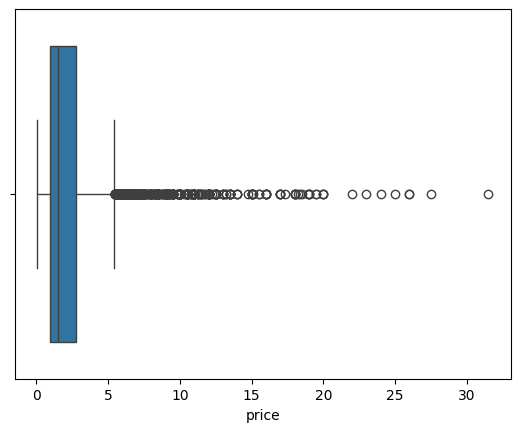

In [8]:
sns.boxplot(x = df['price'])

In [10]:
# calculate the IQR for the 'price' columns

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[ (df['price'] < lower_bound) | (df['price'] > upper_bound)]

num_outliers = outliers.shape[0]
outliers_price_stats = outliers['price'].describe()

num_outliers, outliers_price_stats

(425,
 count    425.000000
 mean       9.235624
 std        4.065259
 min        5.460000
 25%        6.460000
 50%        8.000000
 75%       10.750000
 max       31.500000
 Name: price, dtype: float64)

In [ ]:
outliers.sort_values('price',ascending=False).head(20) # some properties are geniun whereas some are outlier 

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3290,house,arjun marg/ sector- 26 phase- 1/ golf course road,sector 26,31.50,35000.0,9000.0,Plot area 1000(836.13 sq.m.),7.0,9.0,3+,3.0,North-East,Moderately Old,NaN,9000.0,NaN,1,1,1,1,0,2,74
2050,house,independent,sector 43,27.50,24366.0,11290.0,Plot area 1254(1048.5 sq.m.),6.0,7.0,3+,3.0,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,1,1,1,42
2900,house,dlf city plots,sector 26,26.00,57206.0,4540.0,Plot area 505(422.24 sq.m.),6.0,7.0,3+,2.0,North-East,New Property,NaN,4545.0,NaN,1,1,0,1,1,1,138
716,house,independent,sector 26,26.00,82540.0,315.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16.0,16.0,3+,4.0,North-West,New Property,NaN,400.0,350.0,1,1,1,1,0,1,72
1915,house,suncity township,sector 54,25.00,31111.0,8040.0,Plot area 1000(836.13 sq.m.),4.0,4.0,3+,2.0,North,Moderately Old,NaN,1000.0,NaN,1,1,1,1,0,0,0
3336,house,emaar the palm springs,sector 54,24.00,600000.0,400.0,Plot area 400(37.16 sq.m.),5.0,5.0,2,1.0,North-East,Old Property,NaN,400.0,NaN,1,1,0,1,0,1,122
1123,house,independent,sector 26,23.00,25556.0,9000.0,Plot area 1000(836.13 sq.m.),4.0,4.0,3+,2.0,South-West,Relatively New,NaN,9000.0,NaN,1,1,1,1,0,1,145
972,house,vipul tatvam villa,sector 48,22.00,26667.0,8250.0,Plot area 1000(836.13 sq.m.),5.0,6.0,3,3.0,NaN,Moderately Old,NaN,1000.0,NaN,0,1,0,0,0,0,54
2856,house,independent,sector 26,20.00,44444.0,4500.0,Plot area 500(418.06 sq.m.),5.0,7.0,3+,3.0,West,Relatively New,NaN,4500.0,NaN,0,1,0,1,0,2,97
2965,house,luxury dlf city floors,sector 26,20.00,48889.0,4090.0,Plot area 500(418.06 sq.m.),16.0,16.0,3+,4.0,NaN,New Property,NaN,500.0,NaN,0,1,0,0,0,1,31


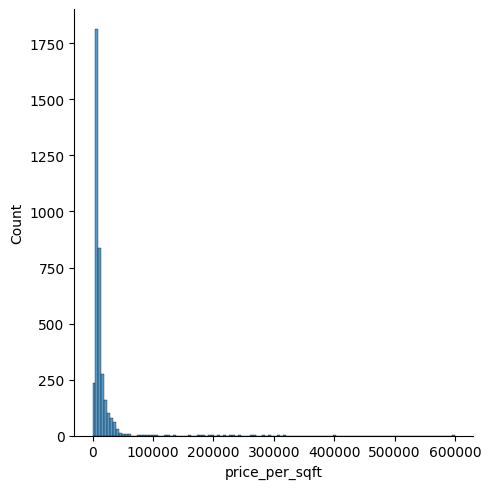

In [ ]:
sns.displot(df['price_per_sqft']) # right skewed 

<Axes: xlabel='price_per_sqft'>

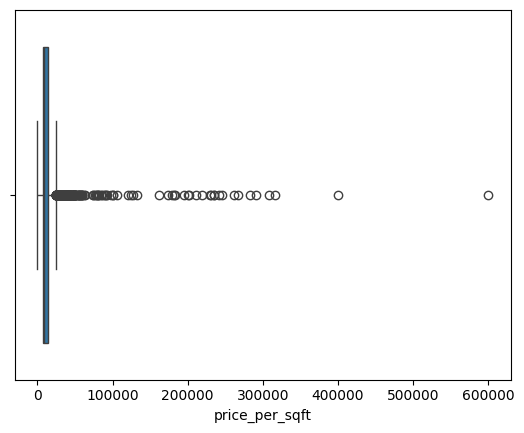

In [13]:
sns.boxplot(x=df['price_per_sqft'])

In [14]:
df[df['area'] < 1000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
11,house,surendra homes dayaindependentd colony,sector 6,0.75,15625.0,48.0,Built Up area: 480 (44.59 sq.m.),4.0,4.0,2,1.0,NaN,Undefined,NaN,480.0,NaN,0,0,0,0,0,0,0
13,flat,bestech park view residency3.,sector 2,0.56,8553.0,655.0,Carpet area: 650 (60.39 sq.m.),1.0,1.0,2,7.0,South-West,Moderately Old,NaN,NaN,650.00,0,0,0,0,0,0,92
14,flat,rof ananda,sector 95,0.25,6578.0,380.0,Super Built up area 380(35.3 sq.m.),1.0,1.0,1,4.0,NaN,New Property,380.0,NaN,NaN,0,0,0,0,0,0,0
21,flat,rof ananda,sector 95,0.46,6318.0,728.0,Carpet area: 728 (67.63 sq.m.),2.0,2.0,2,11.0,North-West,New Property,NaN,NaN,728.00,1,0,0,0,0,0,82
29,house,emaar mgf marbella,sector 66,19.00,31666.0,600.0,Plot area 9000(836.13 sq.m.)Carpet area: 6000 ...,5.0,6.0,3+,3.0,North-East,Relatively New,NaN,NaN,6000.00,0,1,1,1,0,1,110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3794,flat,mvn athens3.,sohna road road,0.27,5901.0,458.0,Carpet area: 457.52 (42.5 sq.m.),2.0,2.0,1,0.0,NaN,Relatively New,NaN,NaN,457.52,0,0,0,0,0,1,69
3795,house,eros rosewood villas,sector 49,2.75,178571.0,15.0,Plot area 154(14.31 sq.m.)Carpet area: 1650 sq...,3.0,3.0,1,2.0,North-West,Old Property,NaN,NaN,1650.00,0,0,0,0,1,1,80
3798,flat,my home,new sector 2,0.22,4400.0,500.0,Carpet area: 500 (46.45 sq.m.),2.0,2.0,1,1.0,NaN,New Property,NaN,NaN,500.00,0,0,0,0,0,1,0
3799,house,independent,sector 37d,1.16,7539.0,154.0,Built Up area: 1535 (142.61 sq.m.),1.0,1.0,0,1.0,NaN,Undefined,NaN,1535.0,NaN,0,0,0,0,0,0,0


In [16]:
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_sqft = df[ (df['price_per_sqft'] < lower_bound ) | (df['price_per_sqft'] > upper_bound)]

num_outliers = outliers_sqft.shape[0]
outliers_sqft_stats = outliers_sqft['price_per_sqft'].describe()

num_outliers, outliers_sqft_stats

(354,
 count       354.000000
 mean      52592.612994
 std       61150.458507
 min       24489.000000
 25%       28208.250000
 50%       33368.500000
 75%       41982.250000
 max      600000.000000
 Name: price_per_sqft, dtype: float64)

In [17]:
outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x : x * 9 if x < 1000 else x)

/var/folders/gb/0twhhzk95yng3hgbcm16f5ph0000gn/T/ipykernel_51511/1803300022.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x : x * 9 if x < 1000 else x)


In [19]:
outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])

/var/folders/gb/0twhhzk95yng3hgbcm16f5ph0000gn/T/ipykernel_51511/3686006548.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])


In [21]:
outliers_sqft['price_per_sqft'].describe()

count       354.000000
mean      39534.533898
std       38164.361555
min        2778.000000
25%       26806.250000
50%       32407.000000
75%       39010.500000
max      350877.000000
Name: price_per_sqft, dtype: float64

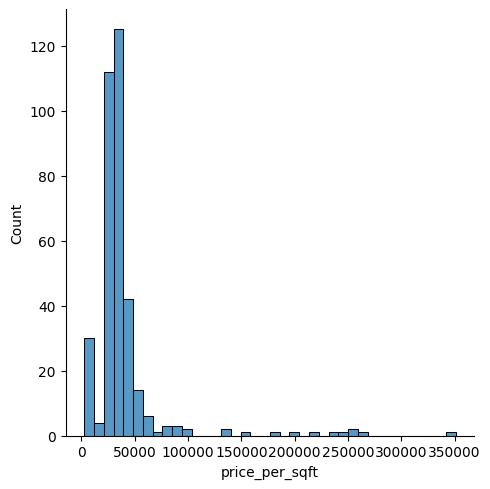

In [22]:
sns.displot(outliers_sqft['price_per_sqft'])

In [23]:
df.update(outliers_sqft)

<Axes: xlabel='price_per_sqft'>

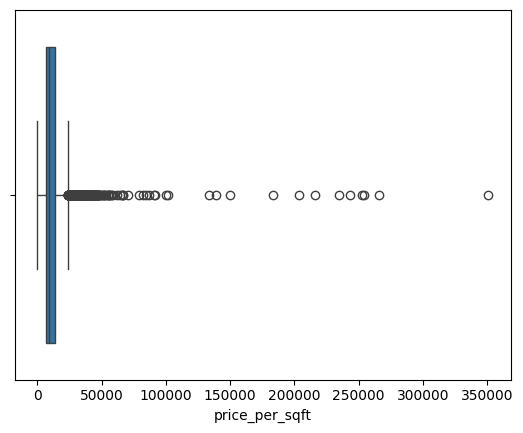

In [24]:
sns.boxplot(x=df['price_per_sqft'])

In [27]:
df[df['price_per_sqft'] > 50000].shape

(38, 23)

In [28]:
df = df[df['price_per_sqft'] <= 50000]

<Axes: xlabel='price_per_sqft'>

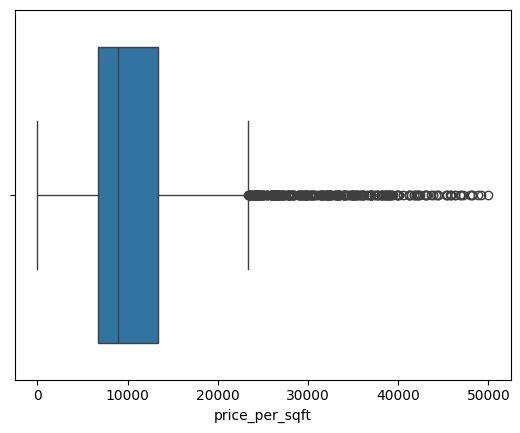

In [30]:
sns.boxplot(x=df['price_per_sqft'])